<a href="https://www.kaggle.com/code/daniilkrizhanovskyi/motion-s-text-to-sign-motion-generation?scriptVersionId=312289782" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Motion-S v5.1: Enhanced Retrieval + Temperature Sweep

**v4 architecture** (no cross-attention = fits T4 16GB) **+ v5 inference:**
- Retrieval weight 0.5 (was 0.35), K=15 (was 10)
- 3-way retrieval: 0.4*gloss + 0.3*sentence + 0.3*combined
- Temperature sweep [0.7, 0.8, 0.9] x 2 candidates = 6 total
- Token frequency bias from training distribution
- Position-smoothed retrieval prior
- Gradient accumulation (eff. batch 96)

---

## 0. Setup

In [1]:
import os, gc, json, math, random, warnings, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

T_START = time.time()
TIME_LIMIT = 8.5 * 3600
def time_left(): return TIME_LIMIT - (time.time() - T_START)
def time_ok(margin=600): return time_left() > margin
print('Setup OK')

Setup OK


In [2]:
def test_cuda():
    if not torch.cuda.is_available(): return False
    try:
        x = torch.randn(2,2,device='cuda')
        _ = F.gelu(x).cpu(); return True
    except: return False

DEVICE = torch.device('cuda' if torch.cuda.is_available() and test_cuda() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Mem: 15.6 GB


In [3]:
import glob
INPUT_DIR = None
for d in sorted(Path('/kaggle/input').iterdir()):
    if (d / 'train.csv').exists(): INPUT_DIR = d; break
if INPUT_DIR is None:
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits: INPUT_DIR = Path(hits[0]).parent
assert INPUT_DIR is not None
print(f'Data: {INPUT_DIR}')

OUTPUT_DIR = Path('/kaggle/working')
TRAIN_CSV = INPUT_DIR / 'train.csv'
TEST_CSV  = INPUT_DIR / 'test.csv'

TOKEN_COLS = ['base_tokens','residual_1','residual_2',
              'residual_3','residual_4','residual_5']

class CFG:
    num_codebook = 512
    num_layers   = 6
    max_seq_len  = 800
    min_seq_len  = 40
    text_dim     = 512
    # Model (same as v4)
    d_model      = 512
    nhead        = 8
    n_enc_layers = 8
    dim_ff       = 2048
    dropout      = 0.1
    # Training
    batch_size   = 48
    accum_steps  = 2       # effective batch = 96
    lr           = 2e-4
    weight_decay = 0.01
    epochs       = 25
    warmup_ratio = 0.08
    grad_clip    = 1.0
    label_smooth = 0.1
    # Inference (v5 upgrades)
    temperatures = [0.7, 0.8, 0.9]
    top_k        = 48
    ret_weight   = 0.5     # up from 0.35
    n_cand_per_t = 2       # 3 temps x 2 = 6 candidates
    ret_k        = 15      # up from 10
    freq_bias_w  = 0.1     # frequency bias weight
print('CFG OK')

Data: /kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language
CFG OK


## 1. Data

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def parse_tokens(s):
    if pd.isna(s) or str(s).strip() == '': return []
    return list(map(int, str(s).strip().split()))

train_df['seq_len'] = train_df['base_tokens'].apply(lambda x: len(parse_tokens(x)))
train_valid = train_df[
    (train_df['seq_len'] >= CFG.min_seq_len) &
    (train_df['seq_len'] <= CFG.max_seq_len)
].copy().reset_index(drop=True)
print(f'Train valid: {len(train_valid)}, Test: {len(test_df)}')

# Pre-parse all train tokens
train_tokens = []
for i in range(len(train_valid)):
    row = train_valid.iloc[i]
    layers = [parse_tokens(row[c]) for c in TOKEN_COLS]
    sl = len(layers[0])
    train_tokens.append(np.array([l[:sl] for l in layers], dtype=np.int64))
print(f'Parsed {len(train_tokens)} token arrays')

# Token frequency bias per layer
print('Computing token frequency bias...')
freq_bias = np.zeros((6, CFG.num_codebook), dtype=np.float32)
for tt in train_tokens:
    for li in range(6):
        for v in tt[li]:
            freq_bias[li, v] += 1
for li in range(6):
    total = freq_bias[li].sum()
    if total > 0:
        freq_bias[li] = np.log(freq_bias[li] / total + 1e-8)
freq_bias_t = torch.tensor(freq_bias, device=DEVICE)
print(f'Freq bias: {freq_bias_t.shape}')
print(f'Time: {time.time()-T_START:.0f}s')

Train valid: 12373, Test: 3000
Parsed 12373 token arrays
Computing token frequency bias...
Freq bias: torch.Size([6, 512])
Time: 136s


## 2. CLIP Encoding (pooled only, fast)

In [5]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers'])
    from transformers import CLIPTokenizer, CLIPTextModel

clip_path = 'openai/clip-vit-base-patch32'
clip_tok = CLIPTokenizer.from_pretrained(clip_path)
clip_mdl = CLIPTextModel.from_pretrained(clip_path).cpu().eval()
for p in clip_mdl.parameters(): p.requires_grad = False
print(f'CLIP loaded: {sum(p.numel() for p in clip_mdl.parameters())/1e6:.0f}M')

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

CLIP loaded: 63M


In [6]:
@torch.no_grad()
def clip_encode(texts, bs=128):
    out = []
    for i in range(0,len(texts),bs):
        inp = clip_tok(texts[i:i+bs], padding='max_length',
                       truncation=True, max_length=77, return_tensors='pt')
        o = clip_mdl(**inp)
        out.append(F.normalize(o.pooler_output, dim=-1))
    return torch.cat(out,0)

print('Encoding texts...')
t0 = time.time()

# All three sets in one pass each
tr_texts_comb = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
                 for _,r in train_valid.iterrows()]
te_texts_comb = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
                 for _,r in test_df.iterrows()]
tr_emb = clip_encode(tr_texts_comb)
te_emb = clip_encode(te_texts_comb)
print(f'  combined: {tr_emb.shape} ({time.time()-t0:.0f}s)')

tr_ge = clip_encode(train_valid['gloss'].tolist())
te_ge = clip_encode(test_df['gloss'].tolist())
print(f'  gloss: {tr_ge.shape} ({time.time()-t0:.0f}s)')

tr_se = clip_encode(train_valid['sentence'].tolist())
te_se = clip_encode(test_df['sentence'].tolist())
print(f'  sentence: {tr_se.shape} ({time.time()-t0:.0f}s)')

del clip_mdl, clip_tok; gc.collect()
print(f'CLIP done: {time.time()-t0:.0f}s')

Encoding texts...
  combined: torch.Size([12373, 512]) (624s)
  gloss: torch.Size([12373, 512]) (1140s)
  sentence: torch.Size([12373, 512]) (1657s)
CLIP done: 1658s


## 3. Enhanced Retrieval (3-way similarity)

In [7]:
K_RET = CFG.ret_k
print(f'Building retrieval index (K={K_RET}, 3-way)...')
t0 = time.time()
N_test = len(test_df); N_train = len(train_valid)

ret_idx = np.zeros((N_test, K_RET), dtype=np.int64)
ret_sim = np.zeros((N_test, K_RET), dtype=np.float32)
CH = 500
for i in range(0, N_test, CH):
    e = min(i+CH, N_test)
    sg = cosine_similarity(te_ge[i:e].numpy(), tr_ge.numpy())
    ss = cosine_similarity(te_se[i:e].numpy(), tr_se.numpy())
    sc = cosine_similarity(te_emb[i:e].numpy(), tr_emb.numpy())
    combined = 0.4 * sg + 0.3 * ss + 0.3 * sc
    for j in range(e-i):
        ix = np.argpartition(combined[j], -K_RET)[-K_RET:]
        ix = ix[np.argsort(combined[j][ix])[::-1]]
        ret_idx[i+j] = ix
        ret_sim[i+j] = combined[j][ix]

print(f'Top-1: mean={ret_sim[:,0].mean():.4f}, min={ret_sim[:,0].min():.4f}')
print(f'Retrieval: {time.time()-t0:.0f}s')
del tr_se, te_se, tr_ge, te_ge; gc.collect()

Building retrieval index (K=15, 3-way)...
Top-1: mean=0.8450, min=0.4608
Retrieval: 1s


0

## 4. Retrieval Token Prior (position-smoothed)

In [8]:
def build_retrieval_prior(test_idx, target_len, layer_idx=0):
    """Build [target_len, 512] soft distribution from top-K neighbors.
    Position-smoothed: adjacent source positions also contribute."""
    prior = np.zeros((target_len, CFG.num_codebook), dtype=np.float32)
    weights = ret_sim[test_idx]
    w = np.exp(weights * 5.0)
    w = w / w.sum()
    
    for k in range(K_RET):
        tr_i = ret_idx[test_idx, k]
        tok_arr = train_tokens[tr_i]
        src_len = tok_arr.shape[1]
        if src_len == 0: continue
        src_tokens = tok_arr[layer_idx]
        for t in range(target_len):
            src_pos = t * src_len / target_len
            sp = min(int(src_pos), src_len - 1)
            prior[t, src_tokens[sp]] += w[k] * 0.7
            if sp > 0:
                prior[t, src_tokens[sp-1]] += w[k] * 0.15
            if sp < src_len - 1:
                prior[t, src_tokens[sp+1]] += w[k] * 0.15
    
    row_sums = prior.sum(axis=1, keepdims=True)
    prior = prior / np.maximum(row_sums, 1e-8)
    return prior

p = build_retrieval_prior(0, 100, 0)
print(f'Prior: {p.shape}, avg entropy={-(p[p>0]*np.log(p[p>0]+1e-10)).sum()/100:.2f}/pos')
print(f'Time: {time.time()-T_START:.0f}s')

Prior: (100, 512), avg entropy=2.33/pos
Time: 1819s


## 5. Hybrid Length Prediction

In [9]:
class LenPred(nn.Module):
    def __init__(self, d=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,128), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(128,1))
    def forward(self, x): return self.net(x).squeeze(-1)

lm = LenPred().to(DEVICE)
lo = torch.optim.AdamW(lm.parameters(), lr=1e-3)
Xl = tr_emb.clone()
yl = torch.log(torch.tensor(train_valid['seq_len'].values, dtype=torch.float32))
ld = DataLoader(torch.utils.data.TensorDataset(Xl, yl), batch_size=512, shuffle=True)

lm.train()
for ep in range(100):
    tl, cnt = 0., 0
    for xb, yb in ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = F.mse_loss(lm(xb), yb)
        lo.zero_grad(); loss.backward(); lo.step()
        tl += loss.item()*len(xb); cnt += len(xb)
    if (ep+1)%50==0: print(f'LenPred ep {ep+1}: MSE={tl/cnt:.4f}')
lm.eval()

@torch.no_grad()
def pred_len_model(emb):
    if emb.dim() == 1: emb = emb.unsqueeze(0)
    p = lm(emb.to(DEVICE))
    return torch.exp(p).round().long().clamp(CFG.min_seq_len, CFG.max_seq_len)

def pred_len_retrieval(test_idx):
    weights = ret_sim[test_idx]
    w = np.exp(weights * 5.0); w = w / w.sum()
    lengths = np.array([train_tokens[ret_idx[test_idx, k]].shape[1]
                        for k in range(K_RET)])
    return int(np.round(np.dot(w, lengths)))

def pred_len_hybrid(test_idx, emb, alpha=0.35):
    """alpha*model + (1-alpha)*retrieval. Lean more on retrieval."""
    lm_pred = pred_len_model(emb).item()
    rt_pred = pred_len_retrieval(test_idx)
    hybrid = int(np.round(alpha * lm_pred + (1 - alpha) * rt_pred))
    return max(CFG.min_seq_len, min(CFG.max_seq_len, hybrid))

for i in range(3):
    ml = pred_len_model(te_emb[i]).item()
    rl = pred_len_retrieval(i)
    hl = pred_len_hybrid(i, te_emb[i])
    print(f'  Test {i}: model={ml}, ret={rl}, hybrid={hl}')
print(f'Time: {time.time()-T_START:.0f}s')

LenPred ep 50: MSE=0.0787
LenPred ep 100: MSE=0.0701
  Test 0: model=116, ret=97, hybrid=104
  Test 1: model=98, ret=119, hybrid=112
  Test 2: model=84, ret=114, hybrid=104
Time: 1831s


## 6. Progressive NAR Model (same arch as v4)

In [10]:
class PosEnc(nn.Module):
    def __init__(self, d, mx=1024):
        super().__init__()
        pe = torch.zeros(mx, d)
        pos = torch.arange(mx).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, T): return self.pe[:,:T,:]


class BaseGen(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model; self.cfg = cfg
        self.txt_proj = nn.Sequential(
            nn.Linear(cfg.text_dim, d), nn.GELU(),
            nn.LayerNorm(d), nn.Linear(d, d))
        self.pos_enc = PosEnc(d, mx=cfg.max_seq_len+1)
        self.len_emb = nn.Embedding(cfg.max_seq_len+1, d)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_enc_layers)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))

    def forward(self, txt_emb, sls, tmask=None):
        B = txt_emb.shape[0]
        T = tmask.shape[1] if tmask is not None else sls.max().item()
        pos = self.pos_enc(T).expand(B,-1,-1)
        txt = self.txt_proj(txt_emb).unsqueeze(1)
        lc = self.len_emb(sls.clamp(0,self.cfg.max_seq_len)).unsqueeze(1)
        x = pos + txt + lc
        kpm = ~tmask if tmask is not None else None
        out = self.encoder(x, src_key_padding_mask=kpm)
        return self.head(out)


class ResidualRefiner(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model; self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.num_codebook, d)
        self.txt_proj = nn.Sequential(
            nn.Linear(cfg.text_dim, d), nn.GELU(), nn.Linear(d, d))
        self.pos_enc = PosEnc(d, mx=cfg.max_seq_len+1)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=6)
        self.heads = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))
            for _ in range(5)])

    def forward(self, txt_emb, base_tokens, sls, tmask=None):
        B, T = base_tokens.shape
        pos = self.pos_enc(T).expand(B,-1,-1)
        txt = self.txt_proj(txt_emb).unsqueeze(1)
        tok = self.tok_emb(base_tokens)
        x = pos + txt + tok
        kpm = ~tmask if tmask is not None else None
        out = self.encoder(x, src_key_padding_mask=kpm)
        return torch.stack([h(out) for h in self.heads], 1)


base_model = BaseGen(CFG).to(DEVICE)
res_model = ResidualRefiner(CFG).to(DEVICE)
bp = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
rp = sum(p.numel() for p in res_model.parameters() if p.requires_grad)
print(f'BaseGen: {bp/1e6:.2f}M, ResRefiner: {rp/1e6:.2f}M, Total: {(bp+rp)/1e6:.2f}M')
print(f'Time: {time.time()-T_START:.0f}s')

BaseGen: 26.42M, ResRefiner: 21.02M, Total: 47.44M
Time: 1831s


## 7. Training

In [11]:
class MotionDS(Dataset):
    def __init__(self, df, embs, tokens_list):
        self.embs = embs
        self.tokens = tokens_list
        self.sls = [t.shape[1] for t in tokens_list]
    def __len__(self): return len(self.tokens)
    def __getitem__(self, i):
        return dict(emb=self.embs[i], tok=self.tokens[i], sl=self.sls[i])

def collate(batch):
    B = len(batch); ms = max(b['sl'] for b in batch)
    emb = torch.stack([b['emb'] for b in batch])
    tok = torch.zeros(B,6,ms, dtype=torch.long)
    tmask = torch.zeros(B,ms, dtype=torch.bool)
    sls = torch.tensor([b['sl'] for b in batch], dtype=torch.long)
    for i,b in enumerate(batch):
        sl = b['sl']
        tok[i,:,:sl] = torch.tensor(b['tok'][:,:sl]); tmask[i,:sl] = True
    return dict(emb=emb, tok=tok, tmask=tmask, sls=sls)

ds = MotionDS(train_valid, tr_emb, train_tokens)
dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=True,
                collate_fn=collate, num_workers=2, pin_memory=True, drop_last=True)
print(f'{len(ds)} samples, {len(dl)} batches')

12373 samples, 257 batches


In [12]:
print('=== Stage 1: Training BaseGen ===')

opt1 = torch.optim.AdamW(base_model.parameters(), lr=CFG.lr,
                         weight_decay=CFG.weight_decay, betas=(0.9,0.98))
total_steps = CFG.epochs * len(dl) // CFG.accum_steps
wu = int(total_steps * CFG.warmup_ratio)
def lr_fn1(s):
    if s < wu: return s/max(1,wu)
    return 0.5*(1+math.cos(math.pi*(s-wu)/max(1,total_steps-wu)))
sch1 = torch.optim.lr_scheduler.LambdaLR(opt1, lr_fn1)
scaler1 = GradScaler()

best1 = float('inf'); hist1 = []; base_model.train(); gs = 0
t_train = time.time()

for ep in range(CFG.epochs):
    if not time_ok(margin=3600):
        print(f'Time guard: stop base ep {ep} ({time_left()/60:.0f}min left)')
        break
    el, et = 0., 0
    opt1.zero_grad()
    for bi, batch in enumerate(dl):
        emb = batch['emb'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)
        tmask = batch['tmask'].to(DEVICE)
        sls = batch['sls'].to(DEVICE)
        base_tgt = tok[:, 0, :]
        
        with autocast():
            logits = base_model(emb, sls, tmask)
            B, T, V = logits.shape
            lf = F.cross_entropy(logits.reshape(-1,V), base_tgt.reshape(-1),
                                 label_smoothing=CFG.label_smooth, reduction='none')
            mf = tmask.reshape(-1).float()
            loss = (lf * mf).sum() / mf.sum() / CFG.accum_steps
        scaler1.scale(loss).backward()
        
        if (bi + 1) % CFG.accum_steps == 0:
            scaler1.unscale_(opt1)
            torch.nn.utils.clip_grad_norm_(base_model.parameters(), CFG.grad_clip)
            scaler1.step(opt1); scaler1.update(); sch1.step()
            opt1.zero_grad(); gs += 1
        
        nt = mf.sum().item()
        el += loss.item() * CFG.accum_steps * nt; et += nt
        if gs > 0 and gs % 100 == 0 and (bi+1) % CFG.accum_steps == 0:
            print(f'  s{gs}: loss={el/et:.4f} lr={sch1.get_last_lr()[0]:.2e}')
    al = el/max(1,et); hist1.append(al)
    ep_t = (time.time()-t_train)/(ep+1)
    print(f'Base ep {ep+1}/{CFG.epochs}: {al:.4f} ({ep_t:.0f}s/ep, {time_left()/60:.0f}min left)')
    if al < best1:
        best1 = al; torch.save(base_model.state_dict(), OUTPUT_DIR/'base_best.pth')
print(f'Base best: {best1:.4f}, time: {time.time()-t_train:.0f}s')

=== Stage 1: Training BaseGen ===
  s100: loss=5.8540 lr=7.81e-05
Base ep 1/25: 5.7667 (62s/ep, 478min left)
  s200: loss=5.1539 lr=1.56e-04
Base ep 2/25: 5.0614 (61s/ep, 477min left)
  s300: loss=4.7741 lr=2.00e-04
Base ep 3/25: 4.6817 (60s/ep, 476min left)
  s400: loss=4.5019 lr=1.99e-04
  s500: loss=4.4543 lr=1.97e-04
Base ep 4/25: 4.4477 (60s/ep, 475min left)
  s600: loss=4.2798 lr=1.93e-04
Base ep 5/25: 4.2843 (60s/ep, 474min left)
  s700: loss=4.1690 lr=1.89e-04
Base ep 6/25: 4.1558 (60s/ep, 473min left)
  s800: loss=4.0157 lr=1.84e-04
Base ep 7/25: 4.0329 (60s/ep, 472min left)
  s900: loss=3.8231 lr=1.77e-04
  s1000: loss=3.9116 lr=1.70e-04
Base ep 8/25: 3.9133 (61s/ep, 471min left)
  s1100: loss=3.7815 lr=1.62e-04
Base ep 9/25: 3.7911 (61s/ep, 470min left)
  s1200: loss=3.6391 lr=1.54e-04
Base ep 10/25: 3.6665 (61s/ep, 469min left)
  s1300: loss=3.5305 lr=1.45e-04
  s1400: loss=3.5475 lr=1.35e-04
Base ep 11/25: 3.5466 (61s/ep, 468min left)
  s1500: loss=3.4271 lr=1.25e-04
Base 

In [13]:
print('=== Stage 2: Training ResidualRefiner ===')

base_model.load_state_dict(torch.load(OUTPUT_DIR/'base_best.pth', map_location=DEVICE))
base_model.eval()

res_epochs = min(CFG.epochs, 20)
opt2 = torch.optim.AdamW(res_model.parameters(), lr=CFG.lr,
                         weight_decay=CFG.weight_decay, betas=(0.9,0.98))
ts2 = res_epochs * len(dl) // CFG.accum_steps
wu2 = int(ts2 * CFG.warmup_ratio)
def lr_fn2(s):
    if s < wu2: return s/max(1,wu2)
    return 0.5*(1+math.cos(math.pi*(s-wu2)/max(1,ts2-wu2)))
sch2 = torch.optim.lr_scheduler.LambdaLR(opt2, lr_fn2)
scaler2 = GradScaler()

best2 = float('inf'); hist2 = []; res_model.train(); gs2 = 0
t_train2 = time.time()

for ep in range(res_epochs):
    if not time_ok(margin=1200):
        print(f'Time guard: stop res ep {ep} ({time_left()/60:.0f}min left)')
        break
    el, et = 0., 0
    opt2.zero_grad()
    for bi, batch in enumerate(dl):
        emb = batch['emb'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)
        tmask = batch['tmask'].to(DEVICE)
        sls = batch['sls'].to(DEVICE)
        base_tok = tok[:, 0, :]
        res_tgt = tok[:, 1:, :]
        
        with autocast():
            logits = res_model(emb, base_tok, sls, tmask)
            B, NL, T, V = logits.shape
            lf = F.cross_entropy(logits.reshape(-1,V), res_tgt.reshape(-1),
                                 label_smoothing=CFG.label_smooth, reduction='none')
            mf = tmask.unsqueeze(1).expand(-1,NL,-1).reshape(-1).float()
            loss = (lf * mf).sum() / mf.sum() / CFG.accum_steps
        scaler2.scale(loss).backward()
        
        if (bi + 1) % CFG.accum_steps == 0:
            scaler2.unscale_(opt2)
            torch.nn.utils.clip_grad_norm_(res_model.parameters(), CFG.grad_clip)
            scaler2.step(opt2); scaler2.update(); sch2.step()
            opt2.zero_grad(); gs2 += 1
        
        nt = mf.sum().item()
        el += loss.item() * CFG.accum_steps * nt; et += nt
        if gs2 > 0 and gs2 % 100 == 0 and (bi+1) % CFG.accum_steps == 0:
            print(f'  s{gs2}: loss={el/et:.4f}')
    al = el/max(1,et); hist2.append(al)
    ep_t = (time.time()-t_train2)/(ep+1)
    print(f'Res ep {ep+1}/{res_epochs}: {al:.4f} ({ep_t:.0f}s/ep, {time_left()/60:.0f}min left)')
    if al < best2:
        best2 = al; torch.save(res_model.state_dict(), OUTPUT_DIR/'res_best.pth')
print(f'Res best: {best2:.4f}, time: {time.time()-t_train2:.0f}s')

=== Stage 2: Training ResidualRefiner ===
  s100: loss=5.7492
Res ep 1/20: 5.5921 (50s/ep, 453min left)
  s200: loss=4.6697
Res ep 2/20: 4.5306 (49s/ep, 453min left)
  s300: loss=4.1982
Res ep 3/20: 4.1008 (50s/ep, 452min left)
  s400: loss=3.9393
  s500: loss=3.8496
Res ep 4/20: 3.8358 (50s/ep, 451min left)
  s600: loss=3.6589
Res ep 5/20: 3.6410 (50s/ep, 450min left)
  s700: loss=3.5113
Res ep 6/20: 3.4885 (50s/ep, 449min left)
  s800: loss=3.4157
Res ep 7/20: 3.3671 (50s/ep, 448min left)
  s900: loss=3.3114
  s1000: loss=3.2690
Res ep 8/20: 3.2692 (50s/ep, 448min left)
  s1100: loss=3.1971
Res ep 9/20: 3.1887 (50s/ep, 447min left)
  s1200: loss=3.1181
Res ep 10/20: 3.1230 (50s/ep, 446min left)
  s1300: loss=3.0778
  s1400: loss=3.0714
Res ep 11/20: 3.0693 (50s/ep, 445min left)
  s1500: loss=3.0276
Res ep 12/20: 3.0246 (50s/ep, 444min left)
  s1600: loss=2.9855
Res ep 13/20: 2.9871 (50s/ep, 443min left)
  s1700: loss=2.9663
Res ep 14/20: 2.9590 (50s/ep, 443min left)
  s1800: loss=2.9

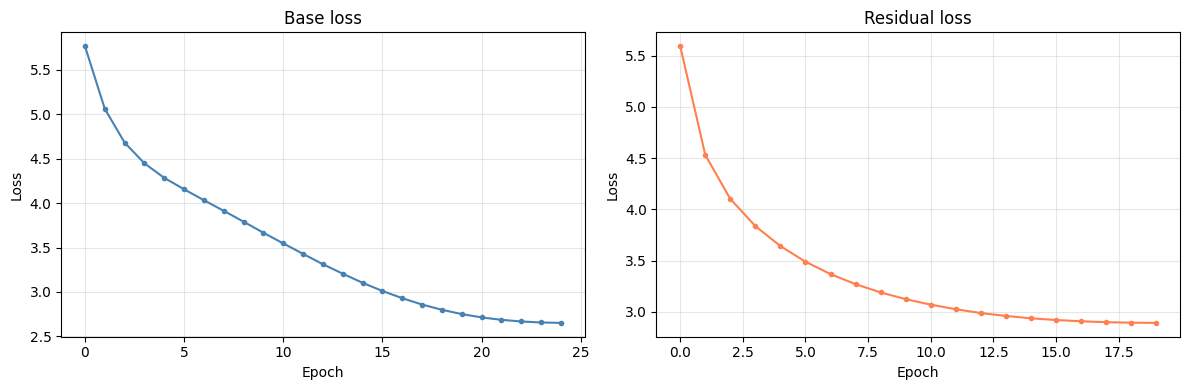

In [14]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(hist1,'o-',color='steelblue',ms=3); ax1.set_title('Base loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True,alpha=0.3)
ax2.plot(hist2,'o-',color='coral',ms=3); ax2.set_title('Residual loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Retrieval-Augmented Inference (temp sweep + freq bias)

In [15]:
base_model.load_state_dict(torch.load(OUTPUT_DIR/'base_best.pth', map_location=DEVICE))
base_model.eval()
res_model.load_state_dict(torch.load(OUTPUT_DIR/'res_best.pth', map_location=DEVICE))
res_model.eval()
print('Models loaded')

Models loaded


In [16]:
@torch.no_grad()
def sample_with_prior(logits_raw, ret_prior_np, freq_b, sl, temps, n_per_t):
    """Sample tokens blending model logits + retrieval prior + freq bias.
    Tries all temps * n_per_t candidates, returns best by log-likelihood."""
    rp_t = torch.log(torch.tensor(ret_prior_np, device=DEVICE, dtype=torch.float32) + 1e-8)
    w = CFG.ret_weight
    fw = CFG.freq_bias_w
    fb = freq_b.unsqueeze(0)  # [1, 512]
    
    best_s = None; best_ll = float('-inf')
    arange_sl = torch.arange(sl, device=DEVICE)
    
    for temp in temps:
        blended = (1 - w) * (logits_raw / temp) + w * rp_t + fw * fb
        if CFG.top_k > 0:
            kv, _ = torch.topk(blended, CFG.top_k, dim=-1)
            blended[blended < kv[:, -1:]] = float('-inf')
        probs = F.softmax(blended, -1)
        for _ in range(n_per_t):
            s = torch.multinomial(probs, 1).squeeze(-1)
            ll = torch.log(probs[arange_sl, s] + 1e-10).sum().item()
            if ll > best_ll:
                best_ll = ll; best_s = s
    return best_s

print('Sampler ready')

Sampler ready


In [17]:
@torch.no_grad()
def generate_batch_v51(start_idx, end_idx):
    B = end_idx - start_idx
    seq_lens = [pred_len_hybrid(i, te_emb[i]) for i in range(start_idx, end_idx)]
    seq_lens_t = torch.tensor(seq_lens, device=DEVICE, dtype=torch.long)
    max_sl = max(seq_lens)
    mask = torch.arange(max_sl, device=DEVICE).unsqueeze(0) < seq_lens_t.unsqueeze(1)
    embs = te_emb[start_idx:end_idx].to(DEVICE)
    
    # Stage 1: Base forward (batched)
    base_logits = base_model(embs, seq_lens_t, mask)  # [B, max_sl, 512]
    
    # Per-sample retrieval + temp sweep sampling
    all_base = torch.zeros(B, max_sl, device=DEVICE, dtype=torch.long)
    for i in range(B):
        ti = start_idx + i
        sl = seq_lens[i]
        bl = base_logits[i, :sl]
        rp = build_retrieval_prior(ti, sl, 0)
        best_s = sample_with_prior(bl, rp, freq_bias_t[0], sl,
                                   CFG.temperatures, CFG.n_cand_per_t)
        all_base[i, :sl] = best_s
    
    # Stage 2: Residual forward (batched)
    res_logits = res_model(embs, all_base, seq_lens_t, mask)  # [B,5,max_sl,512]
    
    results = []
    for i in range(B):
        ti = start_idx + i
        sl = seq_lens[i]
        layers = [all_base[i, :sl].cpu().numpy()]
        for li in range(5):
            rl = res_logits[i, li, :sl]
            rp = build_retrieval_prior(ti, sl, li+1)
            best_rs = sample_with_prior(rl, rp, freq_bias_t[li+1], sl,
                                       CFG.temperatures, CFG.n_cand_per_t)
            layers.append(best_rs.cpu().numpy())
        results.append(np.stack(layers, 0))
    return results

print('Batch generator ready')

Batch generator ready


In [18]:
print(f'Generating {len(test_df)} predictions...')
t0 = time.time()
BATCH_INF = 32
all_preds = []

for i in range(0, len(test_df), BATCH_INF):
    e = min(i + BATCH_INF, len(test_df))
    batch_results = generate_batch_v51(i, e)
    all_preds.extend(batch_results)
    if (i + BATCH_INF) % 200 < BATCH_INF:
        elapsed = time.time() - t0
        rate = max((i + BATCH_INF) / elapsed, 0.01)
        eta = (len(test_df) - i - BATCH_INF) / rate
        print(f'  {min(e,len(test_df))}/{len(test_df)} '
              f'({elapsed:.0f}s, ETA ~{eta:.0f}s)')

print(f'Inference done: {time.time()-t0:.1f}s')
print(f'Total: {(time.time()-T_START)/60:.1f}min')

Generating 3000 predictions...
  224/3000 (10s, ETA ~120s)
  416/3000 (18s, ETA ~111s)
  608/3000 (27s, ETA ~105s)
  800/3000 (34s, ETA ~94s)
  1024/3000 (43s, ETA ~83s)
  1216/3000 (51s, ETA ~74s)
  1408/3000 (58s, ETA ~66s)
  1600/3000 (66s, ETA ~58s)
  1824/3000 (75s, ETA ~48s)
  2016/3000 (82s, ETA ~40s)
  2208/3000 (90s, ETA ~32s)
  2400/3000 (98s, ETA ~24s)
  2624/3000 (106s, ETA ~15s)
  2816/3000 (114s, ETA ~7s)
  3000/3000 (121s, ETA ~-0s)
Inference done: 121.0s
Total: 74.4min


## 9. Retrieval Fallback

In [19]:
def ret_submission():
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        for k in range(K_RET):
            tr_i = ret_idx[i, k]
            tok = train_tokens[tr_i]
            sl = tok.shape[1]
            if CFG.min_seq_len <= sl <= CFG.max_seq_len and sl > 0: break
        if sl < CFG.min_seq_len:
            pad = CFG.min_seq_len - sl
            tok = np.concatenate([tok, np.repeat(tok[:, -1:], pad, axis=1)], axis=1)
        elif sl > CFG.max_seq_len:
            tok = tok[:, :CFG.max_seq_len]
        elif sl == 0:
            tok = np.zeros((6, 60), dtype=np.int64)
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS): d[cn] = ' '.join(map(str, tok[li].tolist()))
        rows.append(d)
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

# Uncomment for pure retrieval:
# sub = ret_submission()
# sub.to_csv(OUTPUT_DIR/'submission.csv', index=False)
print('Retrieval fallback ready')

Retrieval fallback ready


## 10. Submission

In [20]:
rows = []
for i, (_, r) in enumerate(test_df.iterrows()):
    tid = r['id']
    tok = np.clip(all_preds[i], 0, 511)
    d = {'id': tid}
    for li, cn in enumerate(TOKEN_COLS):
        d[cn] = ' '.join(map(str, tok[li].tolist()))
    rows.append(d)
sub = pd.DataFrame(rows)[['id']+TOKEN_COLS]
sub.to_csv(OUTPUT_DIR/'submission.csv', index=False)
print(f'Saved: {len(sub)} rows')
sub.head(3)

Saved: 3000 rows


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 316 308 253 236 236 236 424 76 386 397 195...,109 125 500 222 274 424 153 498 499 498 156 17...,119 313 367 445 455 167 367 394 372 295 502 22...
1,6420682,130 326 276 174 207 174 95 174 174 95 95 95 28...,339 194 194 88 87 88 333 333 258 175 333 333 3...,48 406 406 202 356 321 6 321 356 325 356 356 3...,72 212 212 308 72 236 397 424 449 191 401 503 ...,64 413 413 222 467 153 361 498 71 316 498 109 ...,489 99 313 367 241 167 241 241 241 241 66 350 ...
2,6425789,130 326 95 272 95 95 95 95 95 95 95 95 95 95 9...,339 194 87 80 333 258 333 258 258 9 333 333 33...,48 48 202 452 356 6 356 202 202 283 356 356 58...,72 212 315 130 118 457 59 401 449 457 401 82 1...,64 413 316 467 71 71 95 498 270 498 498 498 43...,489 241 367 372 119 9 241 305 266 459 431 241 ...


## 11. Validation

In [21]:
def validate(df, n=3000):
    errs = []
    if len(df) - n: errs.append(f'Rows: {len(df)} expected {n}')
    for idx, row in df.iterrows():
        lens = []
        for c in TOKEN_COLS:
            toks = str(row[c]).split(); lens.append(len(toks))
            for t in toks:
                v = int(t)
                if v < 0 or v > 511: errs.append(f'R{idx} {c}: {v}'); break
        if len(set(lens)) > 1: errs.append(f'R{idx}: lens {lens}')
        if lens[0] < 40 or lens[0] > 800: errs.append(f'R{idx}: len {lens[0]}')
        if len(errs) > 10: break
    return errs

errs = validate(sub)
if errs:
    for e in errs: print(f'  x {e}')
else:
    print('All checks passed')
sl_dist = sub['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'Len: min={sl_dist.min()} max={sl_dist.max()} mean={sl_dist.mean():.0f}')
print(f'Total time: {(time.time()-T_START)/60:.1f} min')

All checks passed
Len: min=65 max=439 mean=105
Total time: 74.4 min


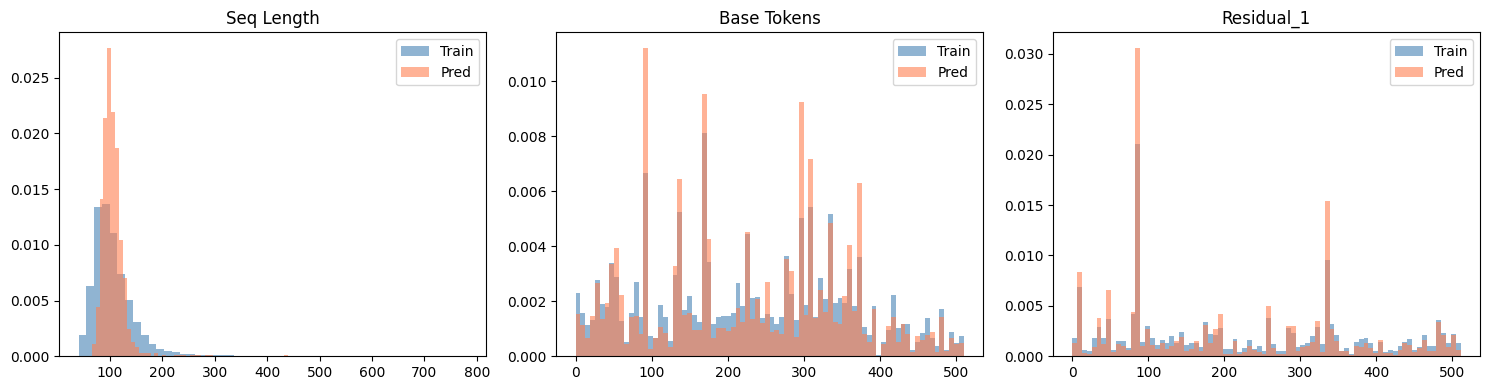

In [22]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
ax = axes[0]
ax.hist(train_valid['seq_len'],bins=50,alpha=.6,label='Train',density=True,color='steelblue')
ax.hist(sl_dist,bins=50,alpha=.6,label='Pred',density=True,color='coral')
ax.set_title('Seq Length'); ax.legend()
ax = axes[1]
tbf=[]; gbf=[]
for _,r in train_valid.head(1000).iterrows(): tbf.extend(parse_tokens(r['base_tokens'])[:100])
for _,r in sub.head(1000).iterrows(): gbf.extend(list(map(int,str(r['base_tokens']).split()[:100])))
ax.hist(tbf,bins=80,alpha=.6,label='Train',density=True,color='steelblue')
ax.hist(gbf,bins=80,alpha=.6,label='Pred',density=True,color='coral')
ax.set_title('Base Tokens'); ax.legend()
ax = axes[2]
trf=[]; grf=[]
for _,r in train_valid.head(1000).iterrows(): trf.extend(parse_tokens(r['residual_1'])[:100])
for _,r in sub.head(1000).iterrows(): grf.extend(list(map(int,str(r['residual_1']).split()[:100])))
ax.hist(trf,bins=80,alpha=.6,label='Train',density=True,color='steelblue')
ax.hist(grf,bins=80,alpha=.6,label='Pred',density=True,color='coral')
ax.set_title('Residual_1'); ax.legend()
plt.tight_layout(); plt.show()

In [23]:
print('='*60)
print('SUMMARY v5.1')
print(f'  Total time: {(time.time()-T_START)/60:.1f} min')
print(f'  Time left: {time_left()/60:.0f} min')
print(f'  Base loss: {best1:.4f}')
print(f'  Residual loss: {best2:.4f}')
print(f'  Predictions: {len(all_preds)}')
print(f'  Retrieval weight: {CFG.ret_weight}')
print(f'  Freq bias weight: {CFG.freq_bias_w}')
print(f'  Temperatures: {CFG.temperatures}')
print(f'  Candidates: {len(CFG.temperatures)*CFG.n_cand_per_t} per sample')
print('='*60)

SUMMARY v5.1
  Total time: 74.4 min
  Time left: 436 min
  Base loss: 2.6524
  Residual loss: 2.8913
  Predictions: 3000
  Retrieval weight: 0.5
  Freq bias weight: 0.1
  Temperatures: [0.7, 0.8, 0.9]
  Candidates: 6 per sample
